In [1]:
import pandas as pd 
df = pd.read_csv("adm_data.csv")
df.columns = df.columns.str.strip()
print(df.head())
print("\nnumber of r and col : ",df.shape )


   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0           1        337          118                  4  4.5  4.5  9.65   
1           2        324          107                  4  4.0  4.5  8.87   
2           3        316          104                  3  3.0  3.5  8.00   
3           4        322          110                  3  3.5  2.5  8.67   
4           5        314          103                  2  2.0  3.0  8.21   

   Research  Chance of Admit  
0         1             0.92  
1         1             0.76  
2         1             0.72  
3         1             0.80  
4         0             0.65  

number of r and col :  (400, 9)


In [2]:
# checking missing values 
print("Missing values: \n",df.isnull().sum())

Missing values: 
 Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


In [3]:
# my data set not contain the missing values so i need to create or insert missing values rendomly so ineed to copy my data set 
d = df.copy()
d = d.drop("Serial No.", axis=1)
# select usefull col
cols = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research"
]

print(cols)


['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']


In [4]:
# now we create missing values i entered the 10% missing values(40 of 400) in every cols
import numpy as np
np.random.seed(42)
# select rendom index od col and create the nan value 
for col in cols:
    idx = np.random.choice(d.index, 40, replace=False)
    d.loc[idx, col] = np.nan
print(d[cols].isnull().sum())
print("Input Shape:", d[cols].shape)

GRE Score            40
TOEFL Score          40
University Rating    40
SOP                  40
LOR                  40
CGPA                 40
Research             40
dtype: int64
Input Shape: (400, 7)


In [5]:
# now we apply knn imputaion method to fill the value 
# knn find the similar stu who have same other col value and estimate the missing values 
from sklearn.impute import KNNImputer
imp = KNNImputer(n_neighbors=5)
# here 5 similar data is look for missing fill
k = d.copy()
k[cols] = imp.fit_transform(k[cols])
print("after knn fill: \n",k.isnull().sum())

after knn fill: 
 GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


In [6]:
# now we use multiple imputation by chained equations(MICE)
# it estimate the missing values fills missing values using relationships between columns. 
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
mice = IterativeImputer(random_state=42)
# copy data for mice
mice_data = d.copy()


In [7]:
print(mice_data[cols].isnull().sum())

GRE Score            40
TOEFL Score          40
University Rating    40
SOP                  40
LOR                  40
CGPA                 40
Research             40
dtype: int64


In [8]:
# apply mice imputetor 
mice_data[cols] = mice.fit_transform(d[cols])
print("After filling:\n",mice_data[cols].isnull().sum())

After filling:
 GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
dtype: int64


In [9]:
#now we use the rendom forest to predict missing values for prediction we need to create all missing cols select targets one by one (using loop)
pred_data = d.copy()

In [10]:
from sklearn.ensemble import RandomForestRegressor
# using for loop to train every feature and make every cols  as targate one by one after every ittretion 
for target in cols:
    train = pred_data[pred_data[target].notnull()]
    test = pred_data[pred_data[target].isnull()]

    if len(test) == 0:
        continue

    features = [col for col in cols if col != target]

    train_x = train[features].fillna(train[features].mean())
    test_x = test[features].fillna(train[features].mean())

    train_y = train[target]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
    model.fit(train_x, train_y)

    predicted = model.predict(test_x)

    pred_data.loc[
        pred_data[target].isnull(),
        target
    ] = predicted

print("after apply prediction :\n",pred_data.isnull().sum())

after apply prediction :
 GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


In [11]:
comparison_missing = pd.DataFrame({
    "knn": k.isnull().sum(),
    "mice": mice_data.isnull().sum(),
    "predictive": pred_data.isnull().sum()
})

print(comparison_missing)

                   knn  mice  predictive
GRE Score            0     0           0
TOEFL Score          0     0           0
University Rating    0     0           0
SOP                  0     0           0
LOR                  0     0           0
CGPA                 0     0           0
Research             0     0           0
Chance of Admit      0     0           0


In [12]:
import matplotlib.pyplot as plt

                     original         knn        mice  predictive
GRE Score          316.807500  316.924500  316.908989  316.890375
TOEFL Score        107.410000  107.363000  107.388075  107.396525
University Rating    3.087500    3.092500    3.093626    3.084950
SOP                  3.400000    3.400000    3.396395    3.394850
LOR                  3.452500    3.442250    3.440042    3.439237
CGPA                 8.598925    8.615745    8.606874    8.607506
Research             0.547500    0.553500    0.555935    0.552550


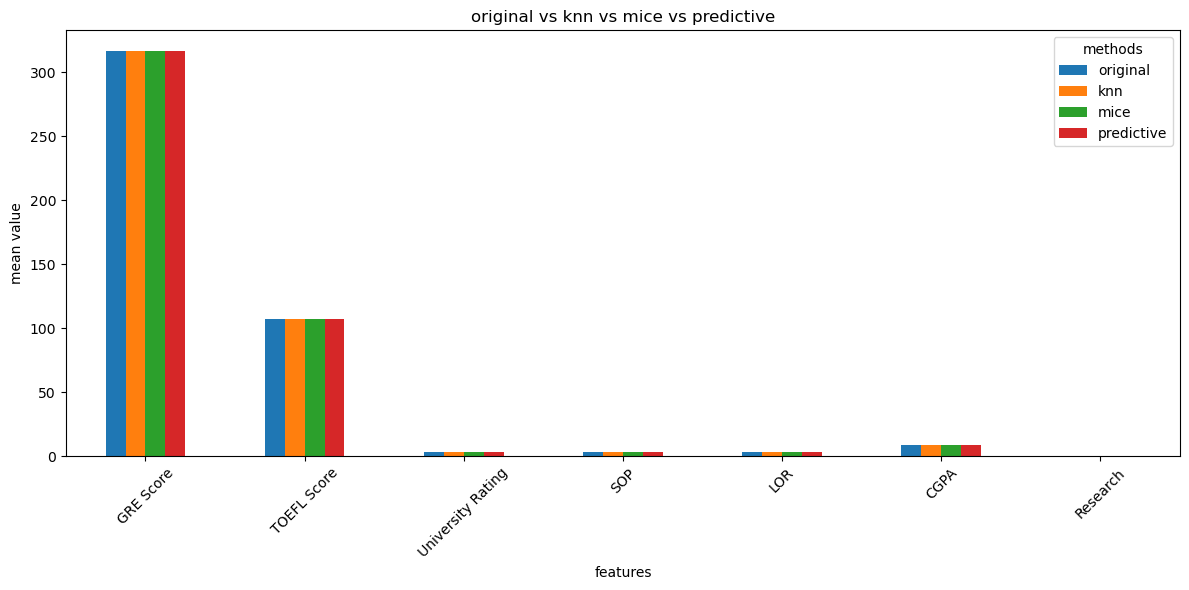

In [13]:
# compair the mean value of the data sets with originals to compair how much data is steel consistant after apply methods.
#(small change = better)

mean_com = pd.DataFrame({
    "original": df[cols].mean(),
    "knn": k[cols].mean(),
    "mice": mice_data[cols].mean(),
    "predictive": pred_data[cols].mean()
})

print(mean_com)

mean_com.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("original vs knn vs mice vs predictive")
plt.ylabel("mean value")
plt.xlabel("features")
plt.xticks(rotation=45)
plt.legend(title="methods")

plt.tight_layout()
plt.show()

                    original        knn       mice  predictive
GRE Score          11.473646  11.041757  11.248898   11.262695
TOEFL Score         6.069514   5.955157   5.963384    5.978773
University Rating   1.143728   1.121288   1.143559    1.129881
SOP                 1.006869   0.980793   0.990772    0.991642
LOR                 0.898478   0.874100   0.884923    0.883217
CGPA                0.596317   0.577335   0.576442    0.574495
Research            0.498362   0.483241   0.477455    0.483042


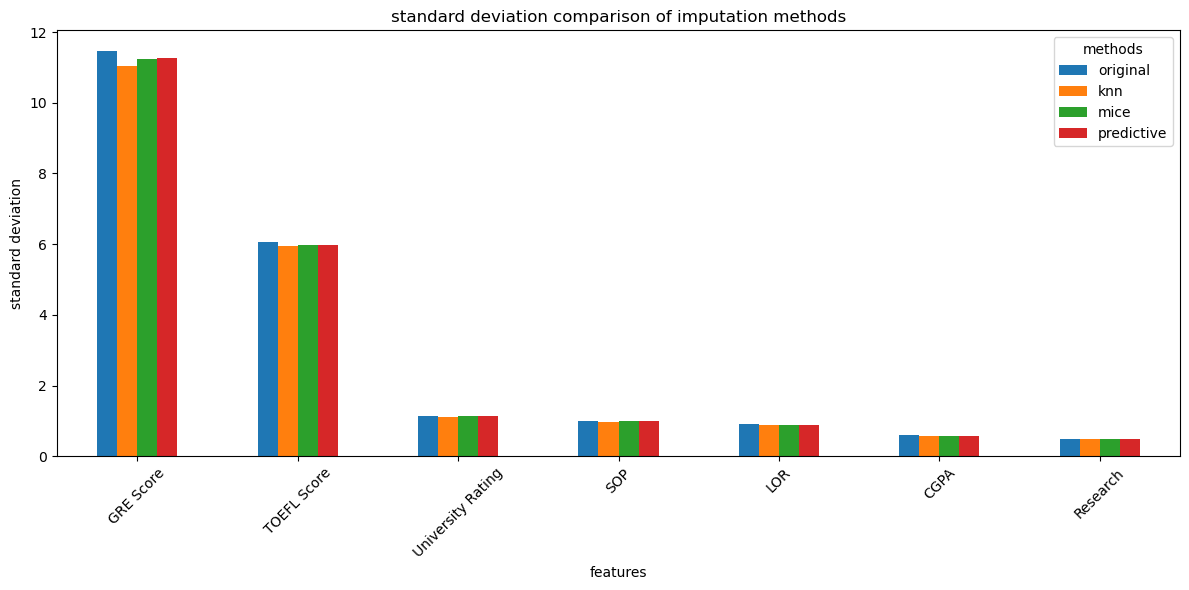

In [14]:
#STD checks whether the data spread is preserved.
# the method keeps data close to original value is batter show

std_com = pd.DataFrame({
    "original": df[cols].std(),
    "knn": k[cols].std(),
    "mice": mice_data[cols].std(),
    "predictive": pred_data[cols].std()
})

print(std_com)

std_com.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("standard deviation comparison of imputation methods")
plt.xlabel("features")
plt.ylabel("standard deviation")
plt.xticks(rotation=45)
plt.legend(title="methods")

plt.tight_layout()
plt.show()

In [15]:
print("original correlation")
print(df[cols].corr())

print("\nknn correlation")
print(k[cols].corr())

print("\nmice correlation")
print(mice_data[cols].corr())

print("\npredictive correlation")
print(pred_data[cols].corr())

original correlation
                   GRE Score  TOEFL Score  University Rating       SOP  \
GRE Score           1.000000     0.835977           0.668976  0.612831   
TOEFL Score         0.835977     1.000000           0.695590  0.657981   
University Rating   0.668976     0.695590           1.000000  0.734523   
SOP                 0.612831     0.657981           0.734523  1.000000   
LOR                 0.557555     0.567721           0.660123  0.729593   
CGPA                0.833060     0.828417           0.746479  0.718144   
Research            0.580391     0.489858           0.447783  0.444029   

                        LOR      CGPA  Research  
GRE Score          0.557555  0.833060  0.580391  
TOEFL Score        0.567721  0.828417  0.489858  
University Rating  0.660123  0.746479  0.447783  
SOP                0.729593  0.718144  0.444029  
LOR                1.000000  0.670211  0.396859  
CGPA               0.670211  1.000000  0.521654  
Research           0.396859  0.52165

In [16]:
# smart compaire
# first the calculation the correlation diffrence between method and original dataset
# then abs calculate the and remove the pos and neg signs,next the average of all differences was calculated. 

knn_diff = (df[cols].corr() - k[cols].corr()).abs().mean().mean()
mice_diff = (df[cols].corr() - mice_data[cols].corr()).abs().mean().mean()
pred_diff = (df[cols].corr() - pred_data[cols].corr()).abs().mean().mean()

print("knn difference:", knn_diff)
print("mice difference:", mice_diff)
print("predictive difference:", pred_diff)

knn difference: 0.010289091284107935
mice difference: 0.01749047683039064
predictive difference: 0.013345147443410654


In [17]:
# lower difference is the knn 0.0102 than others 
# it mean it best method to preserved the original relationships among variables aftre the fill missing value 